In [1]:
# Alex Medina
# AST5765
# HW 8
# 17 October 2025

In [2]:
##### IMPORTS

import os
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as fits

In [3]:
print('Problem 1 \n')

Problem 1 



In [4]:
##### FROM HW7/PRACTICUM

datadir = "hw7_data/"
fext    = ".fits"

objfile  = []
darkfile = []

for filename in os.listdir(datadir):
    if filename.startswith('stars_13s_'):
        file = filename.split(fext)[0]
        objfile.append(file)
    elif filename.startswith('dark_13s_'):
        file = filename.split(fext)[0]
        darkfile.append(file)

objfile, darkfile = sorted(objfile), sorted(darkfile)

# Choosing a random indice from the list
randf  = objfile[int(np.random.uniform(0, len(objfile)))]
file   = fits.getdata(datadir + randf + fext)
nx, ny = file.shape

nobj, ndark = len(objfile), len(darkfile)

objarr  = np.zeros( (nobj, ny, nx))
darkarr = np.zeros( (ndark, ny, nx))

for i in range(nobj):
    if i < nobj - 1:
        objarr[i, :, :] = fits.getdata(datadir + objfile[i] + fext)
    else:
        objarr[i, :, :], objhead = fits.getdata(datadir + objfile[i] + fext, header=True)

for i in range(ndark):
    if i < ndark - 1:
        darkarr[i, :, :] = fits.getdata(datadir + darkfile[i] + fext)
    else:
        darkarr[i, :, :], darkhead = fits.getdata(datadir + darkfile[i] + fext, header=True)

In [5]:
# Median combine the image using np.median(arr, axis=axis)
darkmed = np.median(darkarr, axis=0)

print(f"Pixel index [217, 184] of dark image is {darkmed[217, 187]}. \n")

Pixel index [217, 184] of dark image is 31.0. 



In [6]:
# Writing the median to header histort
darkhead.add_history('The image is a median combination dark frame.')

# Saving as a fits with the new header using writeto
fits.writeto('dark_13s_med.fits', darkmed, header=darkhead, overwrite=True)
print('New .fits created and added with header. \n')
#new = fits.getdata('dark_13s_med.fits', header=True)
#print(new)

# Subtract median combined image from each objarr frame
obj_sub_med = objarr - darkmed

# Write first frame to save
fits.writeto('hw7_amedina_prob2_graph1.fits', obj_sub_med[0], overwrite=True)

New .fits created and added with header. 



In [7]:
# Pixel values before and after subtraction
print(f"Pixel index [217, 184] of first obj frame: {objarr[0, 217, 187]}.")
print(f"Pixel index [217, 184] of first obj frame after: {obj_sub_med[0, 217, 187]}. \n")

Pixel index [217, 184] of first obj frame: 11111.0.
Pixel index [217, 184] of first obj frame after: 11080.0. 



In [8]:
print('Problem 3 \n')

Problem 3 



In [14]:
def normmedcomb(arr, region=( (None, None), (None, None)) ):

    nz, ny, nx = arr.shape

    ( (y1, x1), (y2, x2) ) = region

    norm_fact = np.zeros( nz )

    norm_array = np.zeros( arr.shape )

    for frame in range( nz ):
        norm_fact[frame] = np.median( arr[frame, y1:y2, x1:x2])
        norm_array[frame, :, :] = arr[frame, :, :] / norm_fact[frame]

    output_array = np.median(norm_array, axis=0)

    return output_array, norm_fact

In [10]:
print('Problem 4 \n')

Problem 4 



In [15]:
norm_region = ( (255, 255), (-255, -255))

norm_obj, norm_fact = normmedcomb(objarr, norm_region)

print(norm_obj.shape)

(1024, 1024)


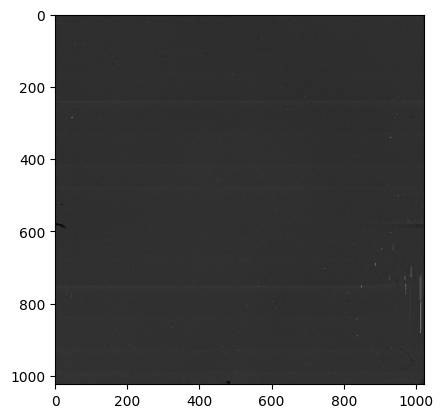

In [16]:
dm = plt.imshow(norm_obj, cmap='gray')